# Regions of Attraction — Three Modes

This notebook demonstrates `CMGDB.cmgdb_roa` on the two-dimensional Leslie
population model.  The model is computed at a subdivision fine enough to resolve
the bistable attractor structure (two attractors), and regions of attraction are
computed three ways:

1. **Default (LCA collapse enabled):** each phase-space box is labelled with the
   unique minimal Morse node it reverse-reaches, or — if it reverse-reaches more
   than one — with the least-common ancestor (LCA) of those minimal nodes in the
   Morse poset.
2. **Multi-label (LCA collapse disabled):** boxes that reverse-reach more than
   one minimal node carry the `MULTI` sentinel; the full reachable-minimal set
   is stored in `reach_mask`.
3. **Explicit LCA collapse:** `collapse_roa_to_lca` is applied to the
   uncollapsed result from mode 2, yielding the same single-label array as
   mode 1.

The Leslie (Beverton–Holt) map is
$$
F\\begin{pmatrix}x_0\\\\x_1\\end{pmatrix}
= \\begin{pmatrix}
(\\theta_1 x_0 + \\theta_2 x_1)\\, e^{-0.1(x_0+x_1)} \\\\
s\\, x_0
\\end{pmatrix},
\\qquad s = 0.7,\\quad \\theta_1 = \\theta_2 = 23.5.
$$
At fine enough subdivision this map admits two attractors separated by a
one-dimensional unstable manifold.

In [1]:
!pip install git+https://github.com/bernardorivas/CMGDB.git

zsh:1: command not found: pip


In [2]:
import math
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import CMGDB
from CMGDB.cmgdb_roa import (
    BOUNDARY,
    ESCAPE,
    MULTI,
    CellROA,
    collapse_roa_to_lca,
    compute_exact_roa,
)
from CMGDB.morse_graph_parser import MorseGraph

## Leslie map definition

This cell is self-contained so the notebook can run independently of other
examples.

In [3]:
THETA_1  = 23.5
THETA_2  = 23.5
SURVIVAL = 0.7


def leslie_map(x):
    """Point map for the 2D Leslie model."""
    return [
        (THETA_1 * x[0] + THETA_2 * x[1]) * math.exp(-0.1 * (x[0] + x[1])),
        SURVIVAL * x[0],
    ]


def leslie_box_map(rect):
    """Corner-based box-map enclosure (no padding)."""
    x0_lo, x1_lo, x0_hi, x1_hi = rect
    corners = [
        leslie_map([x0_lo, x1_lo]),
        leslie_map([x0_hi, x1_lo]),
        leslie_map([x0_lo, x1_hi]),
        leslie_map([x0_hi, x1_hi]),
    ]
    y0_vals = [c[0] for c in corners]
    y1_vals = [c[1] for c in corners]
    return [min(y0_vals), min(y1_vals), max(y0_vals), max(y1_vals)]

## CMGDB parameters

Resolving the bistable structure requires finer subdivision than a coarse
identification pass; the two recurrent orbits sit close in phase space and merge
at coarser grids.  `subdiv_init=23, subdiv_min=23, subdiv_max=25` reliably
separates both attractors and completes in roughly 45 seconds on a laptop.

Note: a trained neural-network map may need `subdiv_init=27, subdiv_min=29,
subdiv_max=30`, where the per-box evaluation
cost is much higher; here the analytic map runs faster per box so the same
separation threshold is reached at lower subdivision depth.


In [4]:
SUBDIV_INIT  = 23
SUBDIV_MIN   = 23
SUBDIV_MAX   = 25
SUBDIV_LIMIT = 10_000

LOWER_BOUNDS = [-0.001, -0.001]
UPPER_BOUNDS = [110.0,   77.0]


## Compute Morse graph and confirm bistability

`MorseGraph.from_dot` parses the CMGDB-emitted DOT string to give a Python
object with DAG algorithms (LCA, reachable-minimal set, etc.).  The DOT source
is extracted from the `graphviz.Source` object returned by `CMGDB.PlotMorseGraph`
and written to a temporary file.

The `minimal` set of a `MorseGraph` is the set of sink nodes (no outgoing
edges), which correspond to attractors in the Conley-Morse framework.

In [5]:
model = CMGDB.Model(
    SUBDIV_MIN, SUBDIV_MAX, SUBDIV_INIT, SUBDIV_LIMIT,
    LOWER_BOUNDS, UPPER_BOUNDS,
    leslie_box_map,
)

print("Running CMGDB (approximately 45 s at subdiv_max=25)...")
cmgdb_morse_graph, map_graph = CMGDB.ComputeMorseGraph(model)
print(f"Done. Morse graph has {cmgdb_morse_graph.num_vertices()} nodes.")

# Build the Python MorseGraph DAG from the CMGDB object.
# CMGDB.PlotMorseGraph returns a graphviz.Source; its .source attribute
# is the DOT string that MorseGraph.from_dot expects.
gv_source = CMGDB.PlotMorseGraph(cmgdb_morse_graph)
with tempfile.NamedTemporaryFile(
    mode="w", suffix=".dot", delete=False
) as tmp:
    tmp.write(gv_source.source)
    dot_path = tmp.name

morse_dag = MorseGraph.from_dot(dot_path)
minimal_nodes = sorted(morse_dag.minimal)
print(f"Minimal (attractor) nodes: {minimal_nodes}")

assert len(minimal_nodes) == 2, (
    f"Expected 2 attractors for bistable Leslie map; found {len(minimal_nodes)}. "
    f"Nodes: {minimal_nodes}. "
    "Increase subdiv_max or check parameters."
)


Running CMGDB (approximately 45 s at subdiv_max=25)...


Done. Morse graph has 5 nodes.
Minimal (attractor) nodes: [0, 1]


## Mode 1 — Default RoA (LCA collapse enabled)

Each cell is assigned the label of the unique minimal Morse node it
reverse-reaches through the map graph.  Cells that reverse-reach more than one
minimal node are assigned the Morse-poset LCA of those nodes.  Cells that escape
all recurrent sets carry `ESCAPE`; cells on a conflict boundary (simultaneous
recurrent ownership) carry `BOUNDARY`.

In [6]:
lower_bounds = np.array(LOWER_BOUNDS, dtype=np.float64)
upper_bounds = np.array(UPPER_BOUNDS, dtype=np.float64)

roa_default = compute_exact_roa(
    map_graph,
    cmgdb_morse_graph,
    morse_dag,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    max_box_geometry_vertices=10_000_000,
    collapse_to_lca=True,
)

n_cells = len(roa_default.box_roa)
for label, name in [(minimal_nodes[0], f"attractor {minimal_nodes[0]}"),
                    (minimal_nodes[1], f"attractor {minimal_nodes[1]}"),
                    (ESCAPE, "escape"), (BOUNDARY, "boundary"), (MULTI, "multi")]:
    count = int(np.sum(roa_default.box_roa == label))
    if count > 0:
        print(f"  {name:>20s}: {count:>8d} cells  ({100*count/n_cells:.1f}%)")
print(f"\n  {'total':>20s}: {n_cells:>8d} cells")


           attractor 0:  6906069 cells  (82.3%)
           attractor 1:   846049 cells  (10.1%)
                escape:       27 cells  (0.0%)

                 total:  8388685 cells


## Mode 2 — Multi-label RoA (LCA collapse disabled)

With `collapse_to_lca=False`, cells that reverse-reach more than one minimal
node are labelled `MULTI` rather than collapsed to the LCA.  The bitmask
`reach_mask[c]` encodes which minimal nodes are reachable from cell $c$:
bit $i$ is set iff `minimal_order[i]` can be reached by reverse-iterating the
map from $c$.

In [7]:
roa_multi = compute_exact_roa(
    map_graph,
    cmgdb_morse_graph,
    morse_dag,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    max_box_geometry_vertices=10_000_000,
    collapse_to_lca=False,
)

n_multi = int(np.sum(roa_multi.box_roa == MULTI))
print(f"Multi-label cells: {n_multi}  ({100*n_multi/n_cells:.2f}% of all cells)")
print(f"These cells collectively form the basin boundary / separatrix region.")


Multi-label cells: 634064  (7.56% of all cells)
These cells collectively form the basin boundary / separatrix region.


## Mode 3 — Explicit LCA collapse

`collapse_roa_to_lca` takes the uncollapsed `CellROA` from mode 2 and replaces
each `MULTI` cell with the LCA of its reachable-minimal set.  The result must
be equal to the default output from mode 1.

In [8]:
roa_lca = collapse_roa_to_lca(roa_multi, morse_dag)

# Verify agreement with mode 1.
assert np.array_equal(roa_lca, roa_default.box_roa), (
    "collapse_roa_to_lca result differs from the default compute_exact_roa output"
)
print("Mode 3 agrees with mode 1: explicit collapse and default collapse are identical.")

Mode 3 agrees with mode 1: explicit collapse and default collapse are identical.


## Phase-space visualisation

Each cell carries a 2D bounding box stored in `roa_default.boxes` (shape
`(n_cells, 4)` with layout `[x0_lo, x1_lo, x0_hi, x1_hi]`).  We render three
panels side by side: the default labels, the multi-label labels, and the
LCA-collapsed labels.  Cells labelled `ESCAPE` are not drawn to keep the plot
legible.

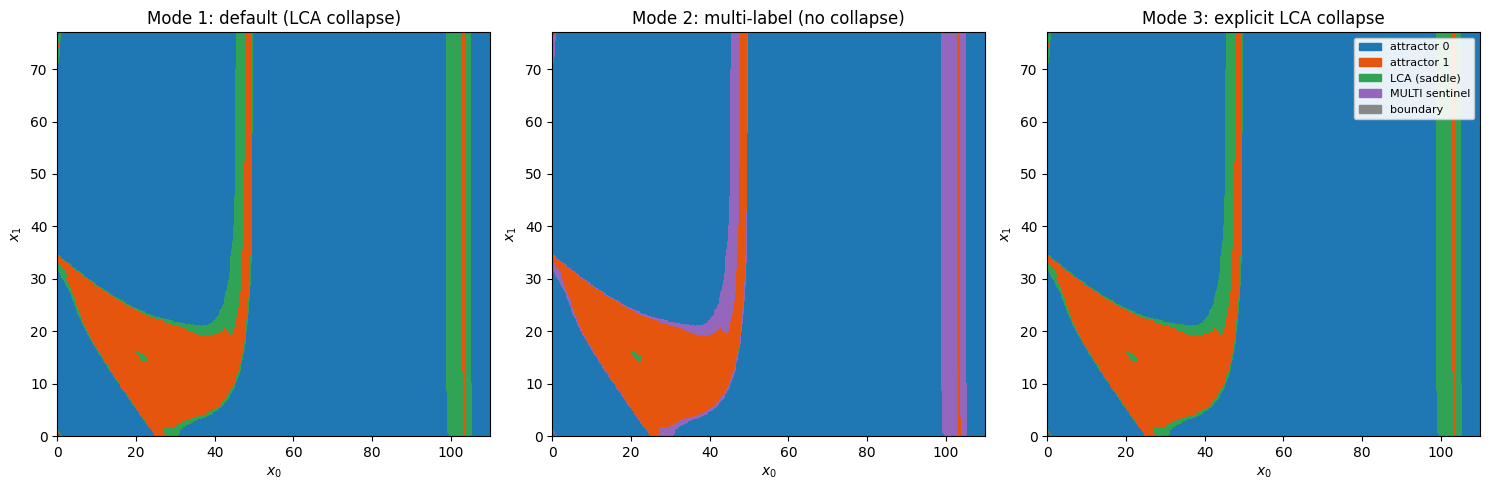

In [9]:
# Map each integer label to a palette index for rasterised rendering.
_LABELS = [int(minimal_nodes[0]), int(minimal_nodes[1]), ESCAPE, BOUNDARY, MULTI]
_LABEL_COLORS = ["#1f77b4", "#e6550d", "#dddddd", "#888888", "#9467bd"]
_LCA_COLOR = "#31a354"

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


def _rasterize(box_roa, boxes, nx=512, ny=360):
    """Map per-cell labels to a pixel grid for fast rendering.

    Each label is converted to a palette index (0 = escape/transparent,
    1..k = attractor/boundary/multi, k+1 = LCA saddle).  The grid is
    filled by cell-center assignment; the last written value wins at each
    pixel, which is adequate for visualisation at this resolution.
    """
    x_lo, x_hi = LOWER_BOUNDS[0], UPPER_BOUNDS[0]
    y_lo, y_hi = LOWER_BOUNDS[1], UPPER_BOUNDS[1]
    cx = (boxes[:, 0] + boxes[:, 2]) * 0.5
    cy = (boxes[:, 1] + boxes[:, 3]) * 0.5
    ix = np.clip(((cx - x_lo) / (x_hi - x_lo) * nx).astype(np.int32), 0, nx - 1)
    iy = np.clip(((cy - y_lo) / (y_hi - y_lo) * ny).astype(np.int32), 0, ny - 1)
    lbl_index = {lbl: k + 1 for k, lbl in enumerate(_LABELS)}
    lca_index = len(_LABELS) + 1
    idx_arr = np.array(
        [lbl_index.get(int(l), lca_index) for l in box_roa], dtype=np.int16
    )
    img = np.zeros((ny, nx), dtype=np.int16)
    img[iy, ix] = idx_arr
    return img


palette = ["white"] + _LABEL_COLORS + [_LCA_COLOR]
cmap = mcolors.ListedColormap(palette)
vmax = len(palette) - 1

boxes = roa_default.boxes
assert boxes is not None, "box geometry not populated; increase max_box_geometry_vertices"

img_default = _rasterize(roa_default.box_roa, boxes)
img_multi   = _rasterize(roa_multi.box_roa,   boxes)
img_lca     = _rasterize(roa_lca,             boxes)

x_lo, x_hi = LOWER_BOUNDS[0], UPPER_BOUNDS[0]
y_lo, y_hi = LOWER_BOUNDS[1], UPPER_BOUNDS[1]
extent = [x_lo, x_hi, y_lo, y_hi]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "Mode 1: default (LCA collapse)",
    "Mode 2: multi-label (no collapse)",
    "Mode 3: explicit LCA collapse",
]
for ax, img, title in zip(axes, [img_default, img_multi, img_lca], titles):
    ax.imshow(
        img, origin="lower", extent=extent, cmap=cmap,
        vmin=0, vmax=vmax, interpolation="nearest", aspect="auto",
    )
    ax.set_xlabel("$x_0$")
    ax.set_ylabel("$x_1$")
    ax.set_title(title)

legend_handles = [
    mpatches.Patch(color=_LABEL_COLORS[0], label=f"attractor {minimal_nodes[0]}"),
    mpatches.Patch(color=_LABEL_COLORS[1], label=f"attractor {minimal_nodes[1]}"),
    mpatches.Patch(color=_LCA_COLOR,       label="LCA (saddle)"),
    mpatches.Patch(color=_LABEL_COLORS[4], label="MULTI sentinel"),
    mpatches.Patch(color=_LABEL_COLORS[3], label="boundary"),
]
axes[2].legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("regions_of_attraction.pdf", bbox_inches="tight")
plt.savefig("regions_of_attraction.png", bbox_inches="tight", dpi=150)
plt.show()


## Interpretation

**Mode 1 and mode 3 are identical** by construction: `collapse_roa_to_lca`
applies exactly the same Morse-poset LCA logic that `compute_exact_roa` applies
internally when `collapse_to_lca=True`.  The difference between modes 1 and 2
is visible along the basin boundary: mode 2 labels those cells `MULTI`
(purple), whereas modes 1 and 3 relabel them with the LCA node (green), which
is the saddle or source that governs the boundary.  In a bistable system with
exactly two attractors, the LCA of both attractors is the unique source in the
Morse poset, so the green cells in modes 1 and 3 correspond precisely to the
separatrix region.  Modes 2 exposes that region explicitly as `MULTI`;
the multi-label representation is useful when the caller wants to post-process
the separatrix geometry further (e.g., estimating its dimension or applying
a different colour per pairwise basin pair).